# California Wildfire PM2.5 Pollution Risk Classifier on Prison and Detention Facilities


## Part 4: Inputting into Models and Assessment
1. Prep and Splitting Data
2. Train Random Forest Regressor (On PM 2.5 Values)
   - 2.1 Time Series Cross Validation
   - 2.2 Training on Full Training Set
   - 2.3 Assessing Random Forest Regressor
3. Transformation of PM2.5 Values to AQI Categories
   - 3.1 Confusion Matrix
   - 3.2 Classification Report
   - 3.3 ROC Curve
4. Model Comparison to Random Forest Classifier
   - 4.1 Classification Report
   - 4.2 ROC Curve
6. Inputting Missing PM2.5 Data in Model

In [1]:
import os
import datetime 

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import RocCurveDisplay, roc_curve, auc
from sklearn.metrics import classification_report

In [2]:
# Obtaining Path files to the data in data folder

directory_name = os.getcwd()
directory_path = Path(directory_name)

# Loading final all pm and missing pm
final_all_pm = pd.read_pickle(directory_path.joinpath('data/final_features_all_pm.pkl'))
final_missing_pm = pd.read_pickle(directory_path.joinpath('data/final_features_missing_pm.pkl'))

## Prep and Split Data

In [3]:
# Final fix on NA values
final_all_pm.fillna({'fire_50km_elevation_max': 0}, inplace=True)
final_missing_pm.fillna({'fire_50km_elevation_max': 0}, inplace=True)

# Due to localization of PurpleAir sensors and EPA sensors, maximimum pm conc will be clipped at 500 
final_all_pm['max_pm_conc'] = final_all_pm['max_pm_conc'].clip(0, 500.0)

In [4]:
# 70-30 training and test split data
X = final_all_pm.drop(columns='max_pm_conc')

X_train = X[(X['Month'] <= 12) & (X['Year'] <= 2023)]
y_train = final_all_pm[(final_all_pm['Month'] <= 12) & (final_all_pm['Year'] <= 2023)]['max_pm_conc']

X_test = X[(X['Month'] <= 12) & (X['Year'] > 2023)]
y_test = final_all_pm[(final_all_pm['Month'] <= 12) & (final_all_pm['Year'] > 2023)]['max_pm_conc']

In [5]:
# Transforming to Log Values
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

## Random Forest Regressor 

### Time Series Cross Validation

In [6]:
# TimeSeries Cross Validation on training data only 
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
tscv =  TimeSeriesSplit(n_splits=5)

scores = cross_val_score(rf_model, X_train, y_train_log, cv=tscv, scoring='neg_root_mean_squared_error')
print(scores)

[-0.73398991 -0.57510914 -0.33112597 -0.47574639 -0.43878009]


### Training on Full Training Set

In [7]:
# Fitting on training data
rf_model.fit(X_train, y_train_log)
y_predicted_log = rf_model.predict(X_test)

# Transform back to real values
y_predicted_real = np.expm1(y_predicted_log)

mae = mean_absolute_error(y_test, y_predicted_real)
mse = mean_squared_error(y_test, y_predicted_real)
rmse = np.sqrt(mse)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")

MAE: 9.268294944455356, MSE: 1142.2995295331777, RMSE: 33.79792197063568


### Assessing Model

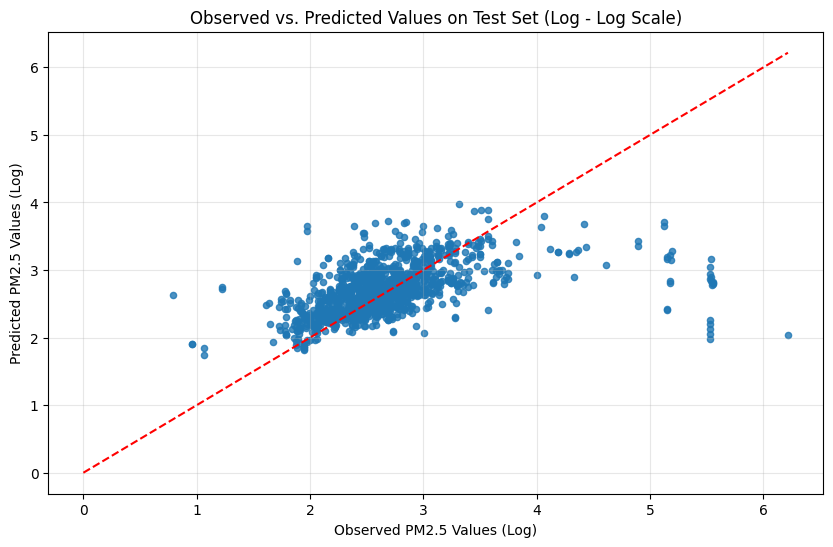

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_log, y_predicted_log, s=20, alpha = 0.8)

limit = max(max(y_test_log), max(y_predicted_log))
plt.plot([0, limit], [0, limit], color='red', linestyle='--')

plt.xlabel('Observed PM2.5 Values (Log)')
plt.ylabel('Predicted PM2.5 Values (Log)')
plt.title('Observed vs. Predicted Values on Test Set (Log - Log Scale)')
plt.grid(True, alpha=0.3)
plt.show()

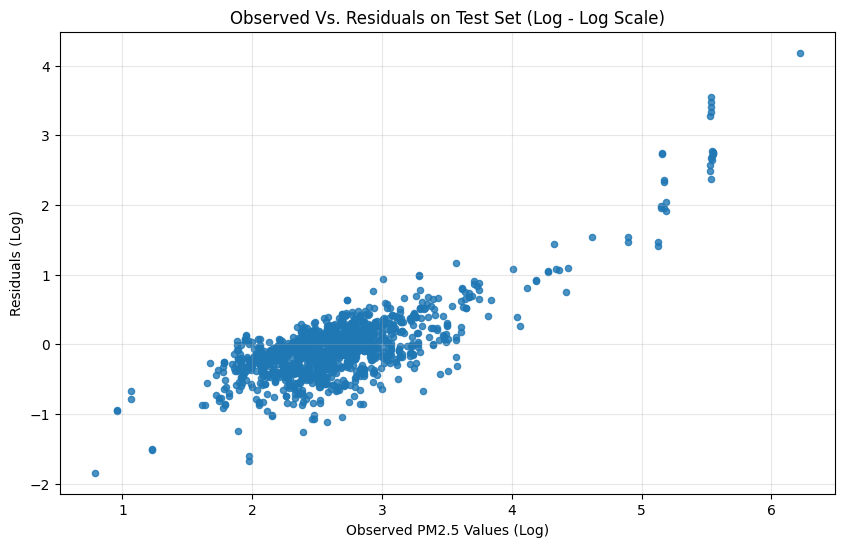

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_log, (y_test_log - y_predicted_log), s=20, alpha = 0.8)

plt.xlabel('Observed PM2.5 Values (Log)')
plt.ylabel('Residuals (Log)')
plt.title('Observed Vs. Residuals on Test Set (Log - Log Scale)')
plt.grid(True, alpha=0.3)
plt.show()

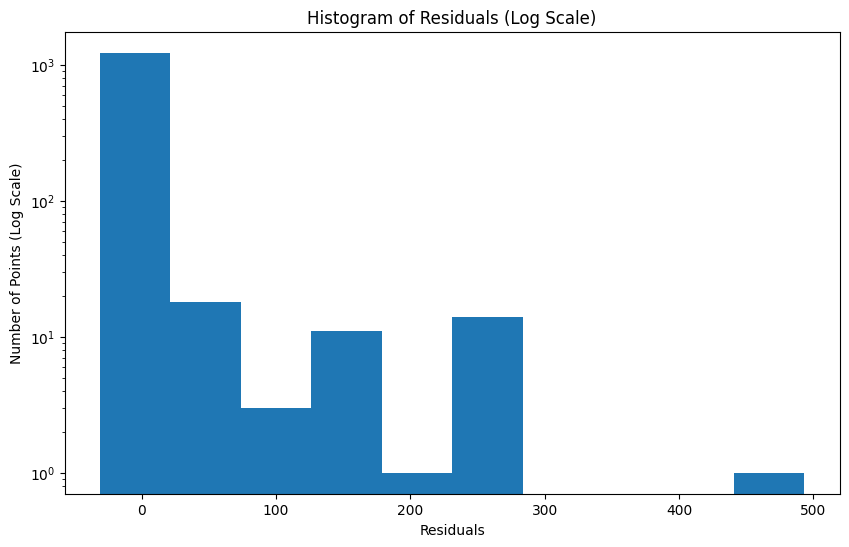

In [10]:
plt.figure(figsize=(10, 6))
plt.hist((y_test - y_predicted_real), bins=10)
plt.yscale('log')

plt.ylabel('Number of Points (Log Scale)')
plt.xlabel('Residuals')
plt.title('Histogram of Residuals (Log Scale)')
plt.show()

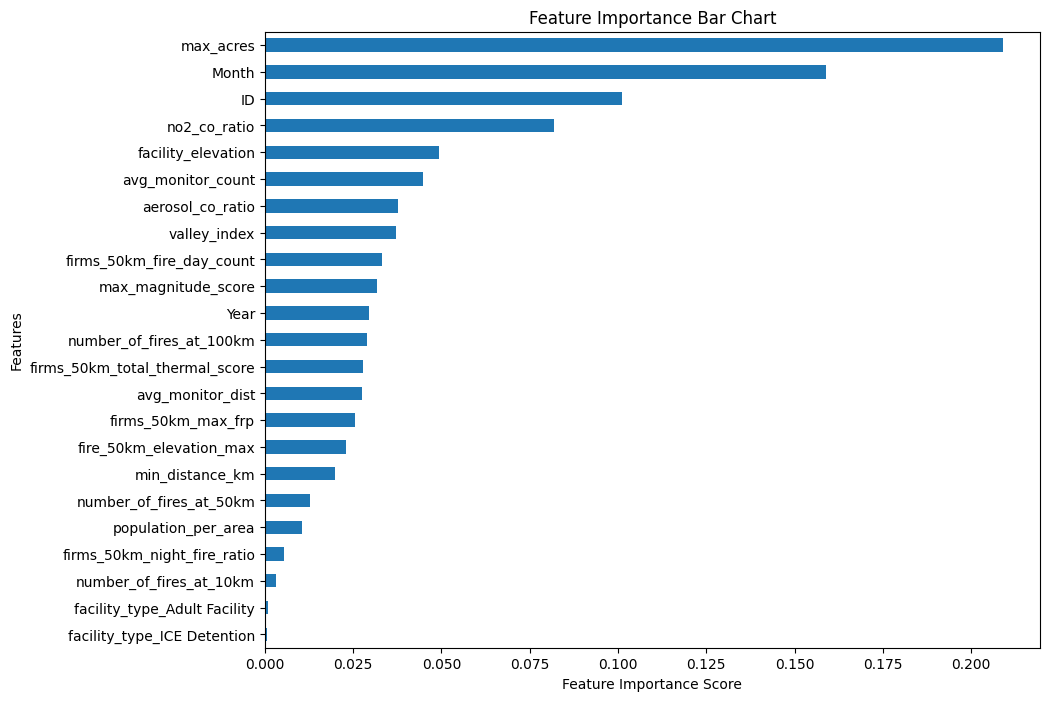

In [11]:
# Feature Importance
feature_importances = pd.Series(
    rf_model.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=True)


feature_importances.plot.barh(figsize=(10, 8))
plt.title('Feature Importance Bar Chart')
plt.ylabel('Features')
plt.xlabel('Feature Importance Score')
plt.show()

## Transformation of PM2.5 Values to AQI Categories

In [12]:
# Copied from Feature Engineering Notebook - where AQI was dropped due to high correlation values from heatmap

# Calculating AQI from the EPA standard conversion
# Ip = Ihi - Ilo
#     ------------  * (Cp - BPlo) + Ilo
#      BPhi - BPlo
# where Ip = the index for pollutant p
# Cp = the truncated concentration of pollutant p
# BPhi = the concentration breakpoint that is greater than or equal to Cp
# BPlo = the concentration breakpoint that is less than or equal to Cp
# Ihi = the AQI value corresponding to BPhi
# Ilo = the AQI value corresponding to BPlo

def pm_to_AQI(pm_conc):
    def breakpoint_range(value):
        if 0.0 <= value <= 9.0:
            return 9.0, 0.0, 50, 0 
        elif 9.1 <= value <= 35.4:
            return 35.4, 9.1, 100, 51
        elif 35.5 <= value <= 55.4:
            return 55.4, 35.4, 150, 101
        elif 55.5 <= value <= 125.4:
            return 125.4, 55.5, 200, 151
        elif 125.5 <= value <= 225.4:
            return 225.4, 125.5, 300, 201
        elif 225.5 <= value <= 500.4:
            return 500.4, 225.5, 500, 301
        else: 
            return 500.4, 225.5, 500, 301 

    truncated_pm_conc = np.round(pm_conc, 1)
    bphi, bplo, ihi, ilo = breakpoint_range(truncated_pm_conc) 

    index_pollutant = ((ihi - ilo) / (bphi - bplo)) * (truncated_pm_conc - bplo) + ilo
    rounded_index_pollutant = int(np.round(index_pollutant))

    if 0.0 <= rounded_index_pollutant <= 50.0:
        return 'Good'
    elif 51.0 <= rounded_index_pollutant <= 100.0:
        return 'Moderate'
    elif 101.0 <= rounded_index_pollutant <= 150.0:
        return 'Unhealthy for Sensitive Groups'
    elif 151.0 <= rounded_index_pollutant <= 200.0:
        return 'Unhealthy'
    elif 201.0 <= rounded_index_pollutant <= 300.0:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

In [13]:
# 3 Risk Category: Low - Mid - High 
def pm_to_risk(value):
    if 0.0 <= value <= 12.0:
        return 'Low Risk'
    elif 12.1 <= value <= 35.4: 
        return 'Moderate Risk'
    else:
        return 'High Risk'

In [14]:
# AQI Categories on y test and predicted
y_test_aqi = y_test.apply(pm_to_AQI)
y_predicted_aqi = pd.Series(map(pm_to_AQI, y_predicted_real))

# 3 Risk Category on y test and predicted
y_train_risk = y_train.apply(pm_to_risk)
y_test_risk = y_test.apply(pm_to_risk)
y_predicted_risk = pd.Series(map(pm_to_risk, y_predicted_real))

### Classification Report

In [15]:
# Classification Report on AQI Categories
print(classification_report(y_test_aqi, y_predicted_aqi))

                                precision    recall  f1-score   support

                          Good       0.67      0.39      0.49       300
                     Hazardous       0.00      0.00      0.00        16
                      Moderate       0.78      0.93      0.85       905
                     Unhealthy       0.00      0.00      0.00        13
Unhealthy for Sensitive Groups       0.00      0.00      0.00        23
                Very Unhealthy       0.00      0.00      0.00        13

                      accuracy                           0.76      1270
                     macro avg       0.24      0.22      0.22      1270
                  weighted avg       0.72      0.76      0.72      1270



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [16]:
# Classification Report on 3-Risk Categories
print(classification_report(y_test_risk, y_predicted_risk))

               precision    recall  f1-score   support

    High Risk       0.21      0.07      0.10        72
     Low Risk       0.76      0.61      0.67       591
Moderate Risk       0.63      0.80      0.71       607

     accuracy                           0.67      1270
    macro avg       0.53      0.49      0.50      1270
 weighted avg       0.67      0.67      0.66      1270



### Confusion Matrix

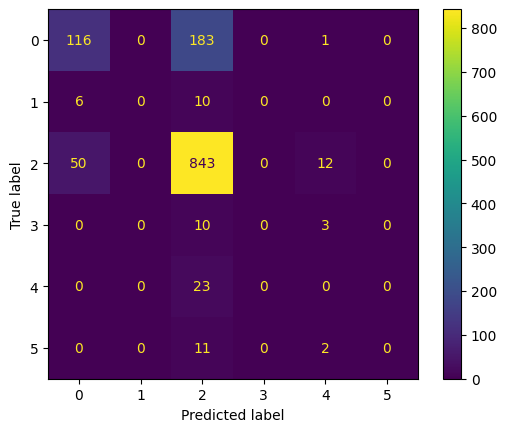

In [17]:
# Confusion Matrix on 6 AQI Categories
cm = confusion_matrix(y_test_aqi, y_predicted_aqi)
cm_display = ConfusionMatrixDisplay(cm).plot()

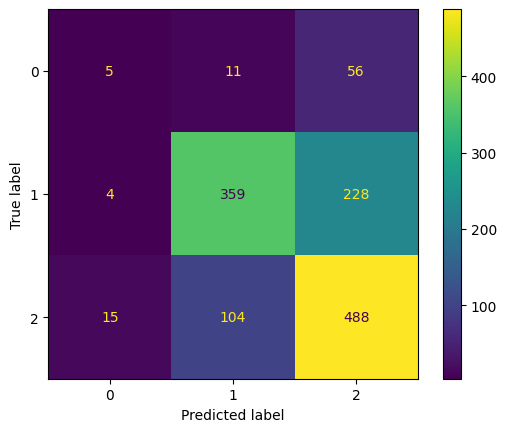

In [18]:
# Confusion Matrix on 3 Risk Category
cm_risk = confusion_matrix(y_test_risk, y_predicted_risk)
cm_display_risk = ConfusionMatrixDisplay(cm_risk).plot()

### ROC Curve 

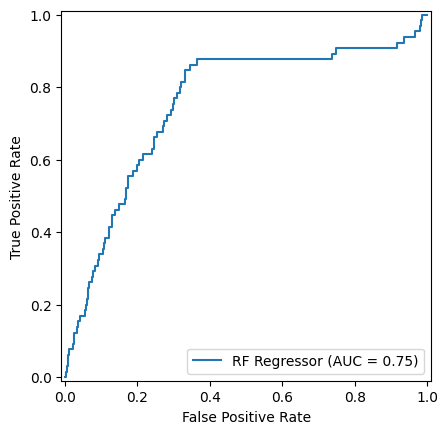

In [19]:
# ROC Curve (Low Risk vs High Risk)
threshold = 35.4  
y_test_binary = (y_test > threshold).astype(int)
fpr, tpr, thresholds = roc_curve(y_test_binary, y_predicted_real)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  name='RF Regressor')
display.plot()
plt.show()

## Random Forest Classifier 

In [20]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', random_state=42)
rf_clf.fit(X_train, y_train_risk)
y_clf_predicted_risk = rf_clf.predict(X_test)

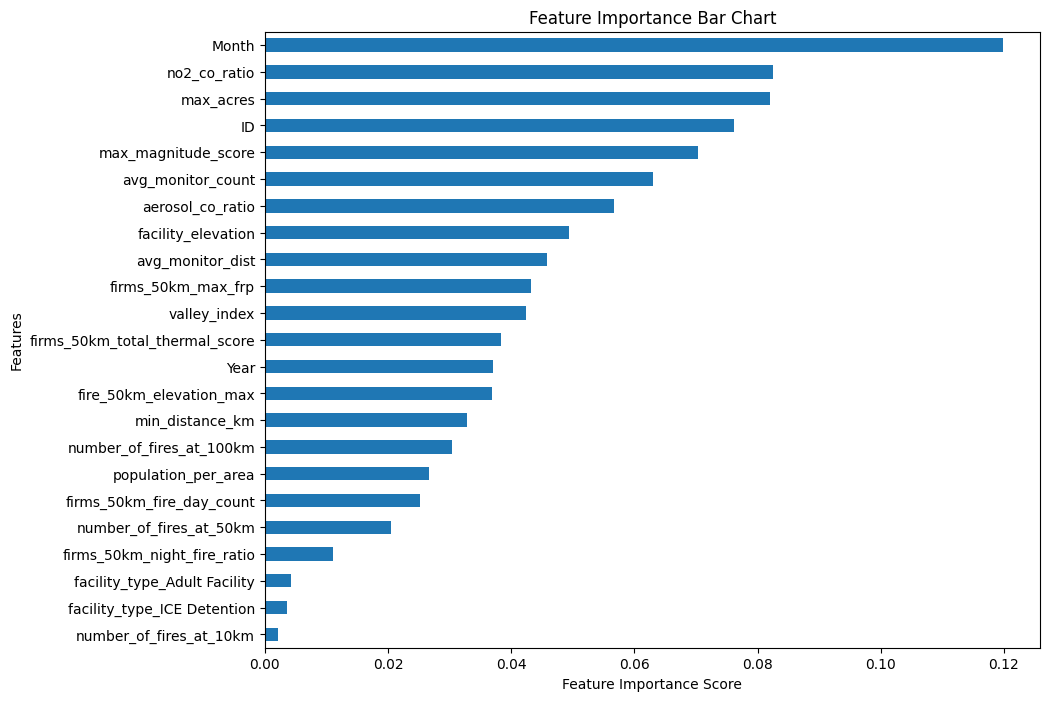

In [21]:
# RF Classifier Feature Importance
feature_importances_cl = pd.Series(
    rf_clf.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=True)


feature_importances_cl.plot.barh(figsize=(10, 8))
plt.title('Feature Importance Bar Chart')
plt.ylabel('Features')
plt.xlabel('Feature Importance Score')
plt.show()

### Classification Report

In [22]:
# Classification Report on 3 Risk Category
print(classification_report(y_test_risk, y_clf_predicted_risk))

               precision    recall  f1-score   support

    High Risk       0.23      0.04      0.07        72
     Low Risk       0.69      0.66      0.67       591
Moderate Risk       0.65      0.74      0.69       607

     accuracy                           0.66      1270
    macro avg       0.52      0.48      0.48      1270
 weighted avg       0.65      0.66      0.65      1270



### Confusion Matrix

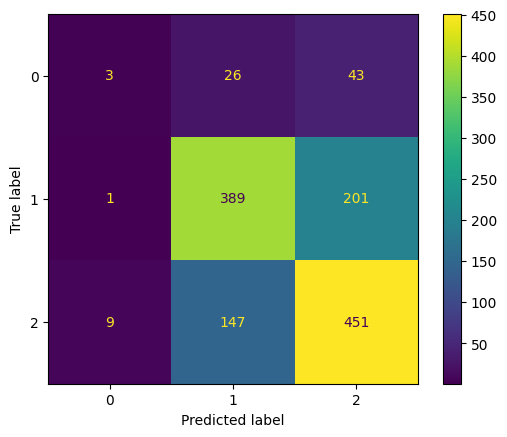

In [23]:
## Confusion Matrix on Classifier
cm_risk_cl = confusion_matrix(y_test_risk, y_clf_predicted_risk)
cm_display_risk_cl = ConfusionMatrixDisplay(cm_risk_cl).plot()

### ROC Curve

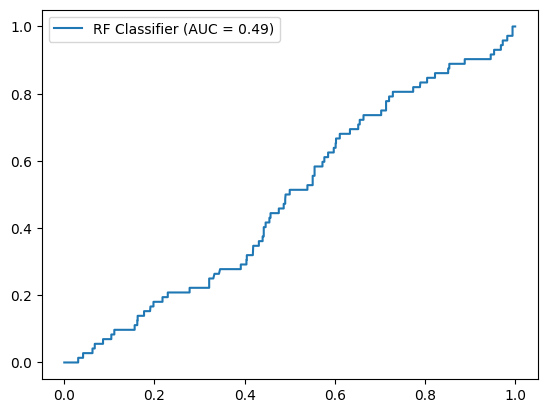

In [24]:
# ROC Curve
y_test_cl_binary = (y_test_risk == 'High Risk').astype(int)
y_probs = rf_clf.predict_proba(X_test)[:, 2]

fpr_clf, tpr_clf, _ = roc_curve(y_test_cl_binary, y_probs)
roc_auc_clf = auc(fpr_clf, tpr_clf)
plt.plot(fpr_clf, tpr_clf, label=f'RF Classifier (AUC = {roc_auc_clf:.2f})')
plt.legend()
plt.show()

## Inputting Missing PM Values into Model

In [25]:
# Ensuring no NA values in final missing pm
final_missing_pm.isna().sum()

min_distance_km                   0
max_magnitude_score               0
max_acres                         0
number_of_fires_at_10km           0
number_of_fires_at_50km           0
number_of_fires_at_100km          0
firms_50km_max_frp                0
firms_50km_total_thermal_score    0
firms_50km_fire_day_count         0
firms_50km_night_fire_ratio       0
fire_50km_elevation_max           0
facility_elevation                0
valley_index                      0
ID                                0
avg_monitor_dist                  0
avg_monitor_count                 0
no2_co_ratio                      0
aerosol_co_ratio                  0
population_per_area               0
facility_type_Adult Facility      0
facility_type_ICE Detention       0
Month                             0
Year                              0
dtype: int64

In [26]:
# Choosing the RandomForestRegressor -> Transformer to Categories for Input Missing Variables
copy_all_pm = final_all_pm.copy()

X_all = copy_all_pm.drop(columns='max_pm_conc')
y = copy_all_pm['max_pm_conc']
log_y = np.log1p(y)

final_rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
final_rf_model.fit(X_all, log_y)

missing_predictions_log = final_rf_model.predict(final_missing_pm)
missing_predictions_real = np.expm1(missing_predictions_log)

In [27]:
# Combining all together 
copy_missing_pm = final_missing_pm.copy()

copy_missing_pm['max_pm_conc'] = missing_predictions_real
copy_missing_pm['Data Status'] = 'Model Prediction'
copy_missing_pm['Actual Risk Tier'] = 'Unknown'
copy_missing_pm['Predicted Risk Tier'] = copy_missing_pm['max_pm_conc'].apply(pm_to_risk)

copy_all_pm['Actual Risk Tier'] = copy_all_pm['max_pm_conc'].apply(pm_to_risk)
copy_all_pm['Predicted Risk Tier'] = pd.Series(y_predicted_real, index=X_test.index).apply(pm_to_risk)

copy_all_pm['Data Status'] = 'Observed Value'
copy_all_pm.loc[X_test.index, 'Data Status'] = 'Validation Period (2024-2025)'


final_deliverable = pd.concat([copy_all_pm, copy_missing_pm]).sort_values(['ID', 'Month', 'Year'])
final_deliverable

,min_distance_km,max_magnitude_score,max_acres,number_of_fires_at_10km,number_of_fires_at_50km,number_of_fires_at_100km,firms_50km_max_frp,firms_50km_total_thermal_score,firms_50km_fire_day_count,firms_50km_night_fire_ratio,...,no2_co_ratio,aerosol_co_ratio,population_per_area,facility_type_Adult Facility,facility_type_ICE Detention,Month,Year,Actual Risk Tier,Predicted Risk Tier,Data Status
1830,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,...,0.001096,-0.037073,0.002879,1.0,0.0,1,2020,Low Risk,NaN,Observed Value
1840,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,...,0.001087,-0.025665,0.002382,1.0,0.0,1,2021,Moderate Risk,NaN,Observed Value
1807,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,...,0.001068,-0.603912,0.002101,1.0,0.0,1,2022,Moderate Risk,NaN,Observed Value
1797,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,...,0.001120,-0.193578,0.001860,1.0,0.0,1,2023,Moderate Risk,NaN,Observed Value
1777,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,...,0.000889,-0.118262,0.001558,1.0,0.0,1,2024,Low Risk,Moderate Risk,Validation Period (2024-2025)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5065,0.000000,0.00000,0.000000,0.0,0.0,0.0,143.35,0.441953,6.0,0.000000,...,0.001954,-0.027647,0.016508,0.0,1.0,12,2020,Unknown,Moderate Risk,Model Prediction
5077,0.000000,0.00000,0.000000,0.0,0.0,0.0,175.34,1.613930,11.0,0.037037,...,0.002750,0.092286,0.035459,0.0,1.0,12,2021,Unknown,Low Risk,Model Prediction
5089,0.000000,0.00000,0.000000,0.0,0.0,0.0,73.35,0.322159,3.0,0.000000,...,0.003085,0.152022,0.035855,0.0,1.0,12,2022,Unknown,Low Risk,Model Prediction
5101,0.000000,0.00000,0.000000,0.0,0.0,0.0,44.18,0.297235,3.0,0.000000,...,0.002445,0.149498,0.041534,0.0,1.0,12,2023,Unknown,Low Risk,Model Prediction


In [28]:
precision_dict = {'Low Risk':'76%',
                  'Moderate Risk': '63%',
                    'High Risk': '21%'}

recall_dict = {'Low Risk':'61%',
                'Moderate Risk': '80%',
                'High Risk':'7%'}

final_deliverable['Model Accuracy'] = '67%'
final_deliverable['Model Precision'] = final_deliverable['Predicted Risk Tier'].map(precision_dict)
final_deliverable['Model Recall'] = final_deliverable['Predicted Risk Tier'].map(recall_dict)

#final_deliverable.to_pickle('final_deliverable.pkl')

,min_distance_km,max_magnitude_score,max_acres,number_of_fires_at_10km,number_of_fires_at_50km,number_of_fires_at_100km,firms_50km_max_frp,firms_50km_total_thermal_score,firms_50km_fire_day_count,firms_50km_night_fire_ratio,...,facility_type_Adult Facility,facility_type_ICE Detention,Month,Year,Actual Risk Tier,Predicted Risk Tier,Data Status,Model Accuracy,Model Precision,Model Recall
1830,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,...,1.0,0.0,1,2020,Low Risk,NaN,Observed Value,67%,NaN,NaN
1840,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,...,1.0,0.0,1,2021,Moderate Risk,NaN,Observed Value,67%,NaN,NaN
1807,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,...,1.0,0.0,1,2022,Moderate Risk,NaN,Observed Value,67%,NaN,NaN
1797,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,...,1.0,0.0,1,2023,Moderate Risk,NaN,Observed Value,67%,NaN,NaN
1777,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,...,1.0,0.0,1,2024,Low Risk,Moderate Risk,Validation Period (2024-2025),67%,63%,80%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5065,0.000000,0.00000,0.000000,0.0,0.0,0.0,143.35,0.441953,6.0,0.000000,...,0.0,1.0,12,2020,Unknown,Moderate Risk,Model Prediction,67%,63%,80%
5077,0.000000,0.00000,0.000000,0.0,0.0,0.0,175.34,1.613930,11.0,0.037037,...,0.0,1.0,12,2021,Unknown,Low Risk,Model Prediction,67%,76%,61%
5089,0.000000,0.00000,0.000000,0.0,0.0,0.0,73.35,0.322159,3.0,0.000000,...,0.0,1.0,12,2022,Unknown,Low Risk,Model Prediction,67%,76%,61%
5101,0.000000,0.00000,0.000000,0.0,0.0,0.0,44.18,0.297235,3.0,0.000000,...,0.0,1.0,12,2023,Unknown,Low Risk,Model Prediction,67%,76%,61%
